In [37]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import losses, applications

In [38]:
image_path = '/kaggle/input/datasets/samvelgalstyan/dataset-cat/cat.jpeg.jfif'
output_path = 'result.png'

In [39]:
model = applications.MobileNetV2(weights='imagenet')

In [40]:
def run_iterative_targeted_attack(image_path, output_path, target_class_idx, steps, alpha, epsilon):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise FileNotFoundError(f"Файл не найден: {image_path}")
        
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))

    original_array = img_resized / 255.0
    original_tensor = tf.convert_to_tensor([original_array], dtype=tf.float32)
    
    perturbed_tensor = tf.identity(original_tensor)

    target_label = keras.utils.to_categorical([target_class_idx], num_classes=1000)
    target_label = tf.convert_to_tensor(target_label, dtype=tf.float32)

    loss_fn = losses.CategoricalCrossentropy(from_logits=False)
    
    print(f"--- Запуск цикла итеративного изменения пикселей (Цель ID: {target_class_idx}) ---")

    for step in range(steps):
        with tf.GradientTape() as tape:
            tape.watch(perturbed_tensor)
            predictions = model(perturbed_tensor)
            current_pred_idx = np.argmax(predictions[0])
            current_prob = predictions[0][target_class_idx] * 100
            print(f"Шаг {step+1}/{steps} | Текущий вердикт модели (ID): {current_pred_idx} | Уверенность в Лимоне: {current_prob:.2f}%")
            if current_pred_idx == target_class_idx and current_prob > 99.0:
                print("Цель достигнута!")
                break
            loss = loss_fn(target_label, predictions)
        gradient = tape.gradient(loss, perturbed_tensor)
        signed_grad = tf.sign(gradient)
        perturbed_tensor = perturbed_tensor - alpha * signed_grad
        perturbed_tensor = tf.clip_by_value(perturbed_tensor, original_tensor - epsilon, original_tensor + epsilon)
        perturbed_tensor = tf.clip_by_value(perturbed_tensor, 0.0, 1.0)

    perturbed_array = perturbed_tensor.numpy()[0]
    perturbed_array = (perturbed_array * 255.0).astype(np.uint8)
    output_bgr = cv2.cvtColor(perturbed_array, cv2.COLOR_RGB2BGR)
    
    cv2.imwrite(output_path, output_bgr)
    print(f"\nФинальный файл сохранен в PNG по пути: {output_path}")

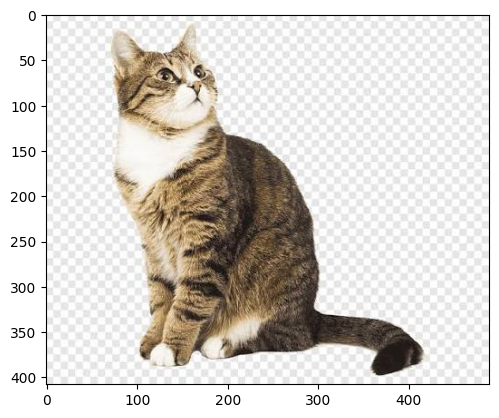

In [41]:
plt.imshow(plt.imread(image_path))

In [42]:
run_iterative_targeted_attack(image_path, output_path, target_class_idx=951, steps=30, alpha=0.002, epsilon=0.02)

--- Запуск цикла итеративного изменения пикселей (Цель ID: 951) ---
Шаг 1/30 | Текущий вердикт модели (ID): 281 | Уверенность в Лимоне: 0.01%
Шаг 2/30 | Текущий вердикт модели (ID): 281 | Уверенность в Лимоне: 0.07%
Шаг 3/30 | Текущий вердикт модели (ID): 281 | Уверенность в Лимоне: 0.21%
Шаг 4/30 | Текущий вердикт модели (ID): 281 | Уверенность в Лимоне: 0.50%
Шаг 5/30 | Текущий вердикт модели (ID): 281 | Уверенность в Лимоне: 0.88%
Шаг 6/30 | Текущий вердикт модели (ID): 281 | Уверенность в Лимоне: 1.42%
Шаг 7/30 | Текущий вердикт модели (ID): 281 | Уверенность в Лимоне: 2.16%
Шаг 8/30 | Текущий вердикт модели (ID): 281 | Уверенность в Лимоне: 3.32%
Шаг 9/30 | Текущий вердикт модели (ID): 281 | Уверенность в Лимоне: 4.88%
Шаг 10/30 | Текущий вердикт модели (ID): 281 | Уверенность в Лимоне: 8.24%
Шаг 11/30 | Текущий вердикт модели (ID): 951 | Уверенность в Лимоне: 12.67%
Шаг 12/30 | Текущий вердикт модели (ID): 951 | Уверенность в Лимоне: 20.51%
Шаг 13/30 | Текущий вердикт модели (ID)

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

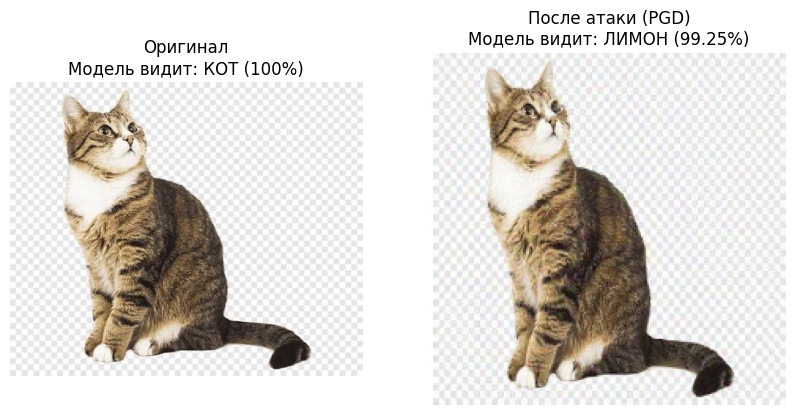

In [44]:
orig = cv2.imread(image_path)
orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)

attacked = cv2.imread('/kaggle/working/result.png')
attacked = cv2.cvtColor(attacked, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(orig)
plt.title("Оригинал\nМодель видит: КОТ (100%)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(attacked)
plt.title("После атаки (PGD)\nМодель видит: ЛИМОН (99.25%)")
plt.axis('off')
